# approve or reject

답변을 승낙 혹은 반려할지.

ex) hallucination -> 분기 -> 
분기단계를 사람이 검증한다.


https://docs.langchain.com/oss/python/langchain/human-in-the-loop

# Review & Edit State

node -> Human -> node 2

human단계에서 사람이 검증함.

retrival 실패 -> rewite
rewite를 사람이 보고 다음 답변을 할지 수정할지 정함

# Review Tool Calls

LLM -> Human -> Tool Executor

LLM이 도구를 사용할때 사람이 검증을 함.

1. just go
2. tool ok query X    쿼리를 수정해서 도구 효율 증가시킴
3. tool x    도구 자체 잘못 셀렉 -> 도구 수정

checkpointer 없이 interrupt 발생 시키면 langgraph 단에서 에러남

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model='gpt-4o')
small_llm = ChatOpenAI(model='gpt-4o-mini')

In [3]:
from langchain_core.tools import tool

@tool  
def add (a: int, b: int) -> int:  
    """숫자 a와 b를 더한 결과를 반환합니다."""   
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱한 결과를 반환합니다."""
    return a * b

In [4]:
!uv pip install -qU langchain-google-community\[gmail\]

In [5]:
from langchain_google_community import GmailToolkit


from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(   
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_sercret_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_toolkit_list = gmail_toolkit.get_tools()

/var/folders/dl/kpb27tds2xvfd5lcdc8n81c40000gn/T/ipykernel_30899/2605579340.py:11: DeprecationWarning: get_gmail_credentials is deprecated and will be removed in a future version.Use get_google_credentials instead.
  credentials = get_gmail_credentials(
/var/folders/dl/kpb27tds2xvfd5lcdc8n81c40000gn/T/ipykernel_30899/2605579340.py:16: DeprecationWarning: build_resource_service is deprecated and will be removed in a future version.Use build_gmail_service instead.
  api_resource = build_resource_service(credentials=credentials)


In [6]:
!uv pip install -qU duckduckgo-search langchain-community ddgs

In [7]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()


In [8]:
!uv pip install -qU langchain-community arxiv

In [9]:
from langchain_community.agent_toolkits.load_tools import load_tools

loaded_tool_list = load_tools(
    ['arxiv'],
    
    )

In [10]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool] + gmail_toolkit_list + loaded_tool_list
llm_with_tools = small_llm.bind_tools(tool_list) 
tool_node = ToolNode(tool_list)

In [11]:
from langgraph.graph import MessagesState, StateGraph

class AgentState(MessagesState):
    summary: str

graph_builder = StateGraph(AgentState)

In [12]:
from langchain_core.messages import SystemMessage

def agent(state: AgentState):
    messages = state['messages']
    summary = state['summary']
    
    if summary != '':
        messages = [SystemMessage(content=f'summarize this chat history below: \n\nchat_history:{messages}\n\nsummary:{summary}')] + messages
    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [ ]:
from typing import Literal
from langgraph.types import Command, interrupt

def human_review(state: AgentState) -> Command[Literal['tools','agent']]:
    messages = state['messages']
    last_message = messages[-1]
    tool_call = last_message.tool.calls[-1]
    human_review = interrupt({
        'question' : '이렇게 진행하면 될까요?',
        'tool_call' : tool_call
    })
    review_action = human_review['action']
    review_data = human_review.get('data', None)

    if review_action == 'continue':
        return Command(goto='tools')
    
    if review_action == 'update_args':
        updated_ai_message = {
            'id': last_message.id,
            'role': 'ai',
            'content': last_message.content,
            'tool_calls': [{
                'id': tool_call['id'],
                'name': tool_call['name'],
                'args': review_data
            }],
        }
        return Command(goto='tools', update={'messages': [updated_ai_message]})
    
    if review_action == 'update_tool':
        updated_tool_message = {
            'tool_call_id': tool_call['id'],
            'name': tool_call['name'],
            'role': 'tool',
            'content': review_data
        }
        return Command(goto='agent', update={'messages': [updated_tool_message]})
    
    

In [14]:
from typing import Literal
from langgraph.graph import END

def should_continue(state: AgentState) -> Literal['tools', END]:
    # 상태에서 메시지를 추출합니다.
    messages = state['messages']
    
    # 마지막 AI 메시지를 가져옵니다.
    last_ai_message = messages[-1]
    
    # 마지막 AI 메시지가 도구 호출을 포함하고 있는지 확인합니다.
    if last_ai_message.tool_calls:
        # 도구 호출이 있으면 'tools'를 반환합니다.
        return 'tools'
    
    # 도구 호출이 없으면 END를 반환하여 프로세스를 종료합니다.
    return END

In [15]:
def summarize_messages(state: AgentState) :
    messages = state['messages']
    summary = state['summary']
    
    summary_prompt = f'summarize this chat history below: \n\nchat_history:{messages}'
    
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
                            chat_history:{messages}
                            summary:{summary}'''
                                        
    summary = small_llm.invoke(summary_prompt)
    
    # 요약된 메시지를 반환합니다.
    return {'summary': summary.content}


In [16]:
from langchain_core.messages import RemoveMessage

def delete_messages(state: AgentState) :
    messages = state['messages']
    delete_messages = [RemoveMessage(id = message.id) for message in messages[:-3]]
    return {'messages' : delete_messages}

In [17]:
def should_continue(state: AgentState) :
    messages = state['messages']
    last_ai_message = messages[-1]
    if last_ai_message.tool_calls:
        return 'human_review'
    
    return 'delete_messages'

In [18]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node(human_review)
graph_builder.add_node('delete_messages', delete_messages)
graph_builder.add_node(summarize_messages)

In [19]:
from langgraph.graph import START, END

graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['human_review', 'summarize_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_messages')
graph_builder.add_edge('delete_messages', END)

In [20]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

graph= graph_builder.compile(checkpointer=checkpointer)

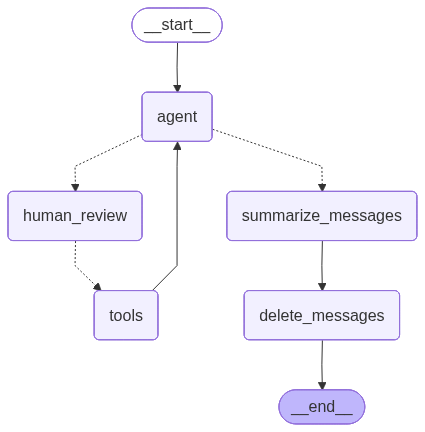

In [21]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
# from langchain_core.messages import HumanMessage
# #query = '윤석열이가 태어난 도시의 화폐 단위는 무엇인가요? 찾아서 ujk6073@gmail.com에 메일 전송해주세요'
# query = '양자컴퓨터에 관련된 논문을찾아서 이메일 초안을 작성해주세요'

# config = {
#     'configurable':{
#         'thread_id': 'paper_summary'
#     }
# }
# for chunk in graph.stream({'messages': [HumanMessage(query)]}, stream_mode='values'):
#     chunk['messages'][-1].pretty_print()

In [ ]:
for chunk in graph.stream(
    Command(resume = {'action' : 'update_args',  'data' :{'Large Language Model : A Survey'}}),
    config = config,
    stream_mode = 'updates'
):
    print(chunk)

In [23]:
# current_message_list = graph.get_state(config).values['messages']
# current_message_list

In [24]:
# from langchain_core.messages import RemoveMessage

# for message, index in enumerate(current_message_list):
#     if index < len(current_message_list) - 1 :
#         graph.update_state(config, {'messages': [RemoveMessage(id = message.id)]})

In [25]:
# current_message_list = graph.get_state(config).values['messages']
# current_message_list